In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 5: a combinatorial explosion

If you have n features, there are 

$$
\dfrac{(n+d-1)!}{d!(n-1)!}
$$

polynomial features of degree $d$.

With $n=20$, plot the number of polynomial features as a function of the degree $d$.

****
So, the thing is, factorials are notoriously troublesome to compute: they grow really fast, and we're limited in memory by the size of integers we like to store. Below, we write a quick loop to show how rapidly we run into memory problems with factorials.

In [21]:
running_total = 1 

for i in np.arange(1,30):
    running_total = running_total * i
    print(running_total)

1
2
6
24
120
720
5040
40320
362880
3628800
39916800
479001600
6227020800
87178291200
1307674368000
20922789888000
355687428096000
6402373705728000
121645100408832000
2432902008176640000
-4249290049419214848
-1250660718674968576
8128291617894825984
-7835185981329244160
7034535277573963776
-1569523520172457984
-5483646897237262336
-5968160532966932480
-7055958792655077376


<ipython-input-21-0087e59f461a>:4: RuntimeWarning: overflow encountered in long_scalars
  running_total = running_total * i


See how Python hates us now? that's a bad thing. Further, a lot of these outputs are eventually negative, even though we multiplied two positive numbers together at every step. I think this is integer overflow but I honestly don't know how that works in Python/NumPy.

So, what do we do instead? I think Stirling's Approximation would give us reasonable results, but they wouldn't necessarily be integral answers. Maybe we'll do that down below. Instead, we can first try using some prebuilt functions that I expect are quite efficient.

In [23]:
from scipy.special import comb # comb is a function that takes inputs n and k and returns n choose k

In [28]:
n = 20
deg_list = np.arange(0,20) # increase input to test more degrees
deg_list

feature_count = [comb(n+i-1,i) for i in deg_list]
feature_count

[1.0,
 20.0,
 210.0,
 1540.0,
 8855.0,
 42504.0,
 177100.0,
 657800.0,
 2220075.0,
 6906900.0,
 20030010.0,
 54627300.0,
 141120525.0,
 347373600.0,
 818809200.0,
 1855967519.9999998,
 4059928949.9999995,
 8597496599.999998,
 17672631899.999996,
 35345263799.99999]

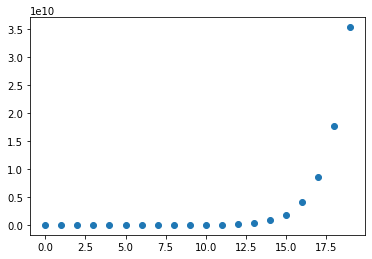

In [29]:
plt.scatter(deg_list,feature_count)

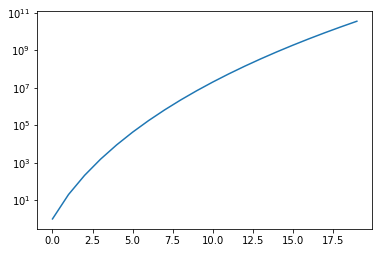

In [30]:
# this plot has kinda bad scale, so lets try a semilogy plot:

plt.semilogy(deg_list,feature_count)

I guess this is neat too. Again, these numbers are getting so big so fast that it's rapidly outside the scope of human understanding. $10^10$ is just a huge number, but that's kind of the point I guess.

****

## Stirling's Approximation

I thought it might be neat to include an approach using Stirling's approximation, which is as follows:
$$ n! \sim \sqrt{2\pi n}\left(\frac{n}{e}\right)^n  $$


In [37]:
def stir(n):
    if n == 0:
        return 1
    else:
        return np.sqrt(2*np.pi*n)*(n/np.e)**n

In [36]:
for i in range(20):
    print(stir(i))

0.0
0.9221370088957891
1.9190043514889832
5.836209591345864
23.506175132893294
118.0191679575901
710.078184642185
4980.395831612462
39902.39545265671
359536.87284194835
3598695.6187410373
39615625.05057755
475687486.47277606
6187239475.19272
86661001740.59883
1300430722199.468
20814114415223.137
353948328666101.1
6372804626194313.0
1.2111278659229419e+17


In [38]:
def stir_binom(n,k):
    if n<k:
        return 0
    else:
        return stir(n)/(stir(k)*stir(n-k))

In [39]:
stir_count = [stir_binom(n+i-1,i) for i in deg_list]

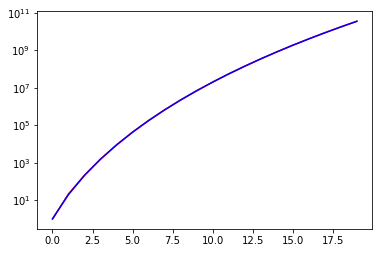

In [51]:
plt.semilogy(deg_list,stir_count,color='red')
plt.semilogy(deg_list,feature_count,color = 'blue')

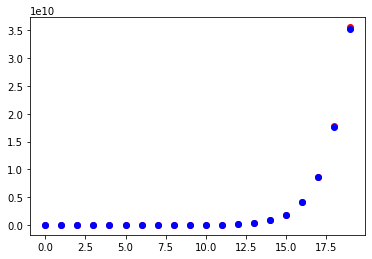

In [52]:
plt.scatter(deg_list,stir_count,color='red')
plt.scatter(deg_list,feature_count,color = 'blue')